In [2]:
import scanpy as sc
import numpy as np
sc.settings.verbosity = 1

adata = sc.read_h5ad("data/processed/01_qc_filtered.h5ad")
print(adata)

/home/ubuntu/miniconda3/envs/scrna/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


AnnData object with n_obs × n_vars = 31265 × 22844
    obs: 'sample', 'subtype', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet'


In [3]:
# 1. Preserve raw counts in a layer (DE needs these later)
adata.layers["counts"] = adata.X.copy()

# 2. Normalize each cell to the same total, then log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 3. Freeze the log-normalized full matrix (annotation/plotting needs this)
adata.raw = adata

print("Counts layer saved:", "counts" in adata.layers)
print("Raw frozen:", adata.raw is not None)

Counts layer saved: True
Raw frozen: True


In [4]:
# Find the most variable genes — these drive cell-type differences
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
print(f"Highly variable genes: {adata.var['highly_variable'].sum()}")

# Keep only HVGs for the downstream clustering steps
adata = adata[:, adata.var["highly_variable"]].copy()

# Scale to unit variance (clip extreme values at 10)
sc.pp.scale(adata, max_value=10)
print("Shape after HVG + scale:", adata.shape)

Highly variable genes: 2000


/home/ubuntu/miniconda3/envs/scrna/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Shape after HVG + scale: (31265, 2000)


In [5]:
# PCA — compress 2000 genes into 50 components capturing main variation
sc.pp.pca(adata, n_comps=50)

# Build the neighbor graph, then UMAP for visualization
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

print("PCA, neighbors, UMAP done.")
print(adata)

/home/ubuntu/miniconda3/envs/scrna/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PCA, neighbors, UMAP done.
AnnData object with n_obs × n_vars = 31265 × 2000
    obs: 'sample', 'subtype', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


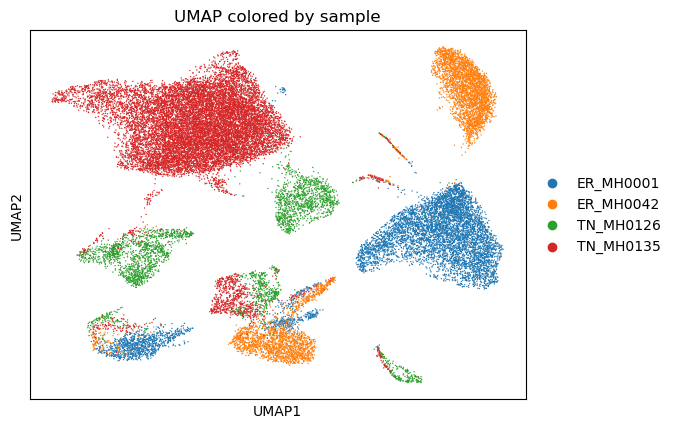

In [6]:
sc.pl.umap(adata, color="sample", title="UMAP colored by sample")

In [10]:
adata.obsm["X_pca_harmony"] = ho.Z_corr
print("Stored shape:", adata.obsm["X_pca_harmony"].shape)

Stored shape: (31265, 50)


In [11]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, use_rep="X_pca_harmony")
sc.tl.umap(adata)
print("Done.")

Done.


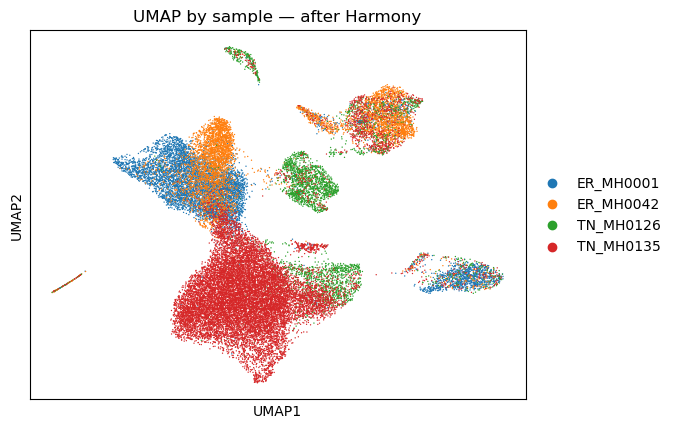

In [12]:
sc.pl.umap(adata, color="sample", title="UMAP by sample — after Harmony")

In [13]:
# Leiden clustering at 3 resolutions — pick the biologically sensible one
for res in [0.3, 0.5, 0.8]:
    sc.tl.leiden(adata, resolution=res, key_added=f"leiden_{res}",
                 flavor="igraph", n_iterations=2)
    n = adata.obs[f"leiden_{res}"].nunique()
    print(f"resolution {res}: {n} clusters")

resolution 0.3: 10 clusters
resolution 0.5: 13 clusters
resolution 0.8: 17 clusters


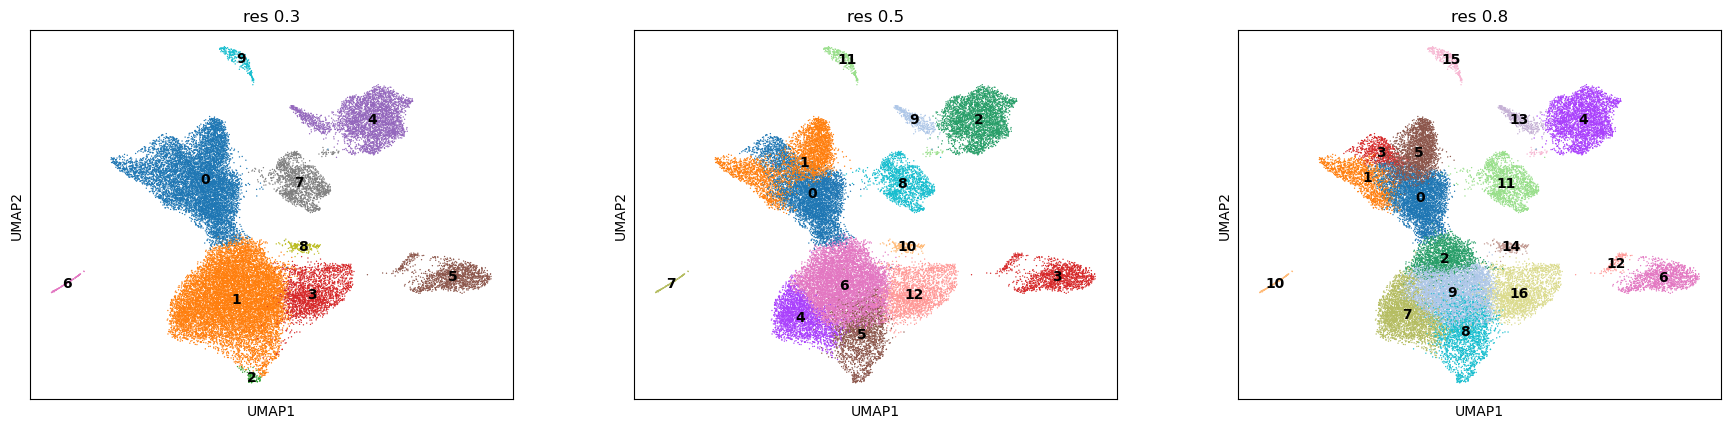

In [14]:
sc.pl.umap(adata, color=["leiden_0.3", "leiden_0.5", "leiden_0.8"],
           legend_loc="on data", ncols=3, title=["res 0.3", "res 0.5", "res 0.8"])

In [15]:
adata.write("data/processed/02_clustered.h5ad")
import os
print("Saved:", os.path.exists("data/processed/02_clustered.h5ad"), adata.shape)

Saved: True (31265, 2000)
